# Kicker Analyse (PAT / Field Goal)

### Vorbereitungen

##### Pakete laden

In [1]:
import nflreadpy as nfl
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns


In [2]:
seasons = np.arange(2015, 2026).tolist() # 2015 - 2025

#### Datengrundlage 

In [3]:
all_kfp = nfl.load_schedules(
    seasons
).select(
    ['game_id', 'season']
).join(
    other=nfl.load_pbp(seasons).filter(
        ((pl.col('extra_point_attempt') == 1) | (pl.col('field_goal_attempt') == 1))
    ).select([
        'season_type', 'game_id',
        'game_seconds_remaining', 'score_differential', 'yardline_100',
        'extra_point_attempt', 'extra_point_prob', 'extra_point_result',
        'field_goal_attempt', 'fg_prob', 'field_goal_result',
        'wp', 'vegas_wpa',
        'kicker_player_name', 'kicker_player_id', 'posteam', 'defteam'
    ]),
    how='left',
    on='game_id'
)


### PAT

In [4]:
pats = all_kfp.filter(pl.col("extra_point_attempt") == 1) # Alle PaTs

pat_stats_overall = (
    pats
    .group_by(["season", "season_type"])
    .agg([
        pl.len().alias("pat_attempts"),
        (pl.col("extra_point_result") == "good").sum().alias("pat_made"),
    ])
    .with_columns([
        (pl.col("pat_made") / pl.col("pat_attempts")).alias("pat_success_rate")
    ])
    .sort(["season", "season_type"])
)

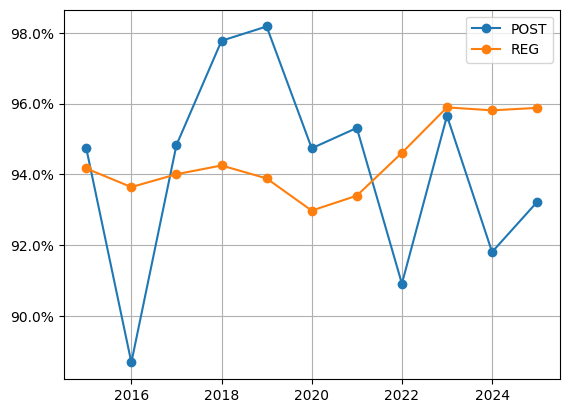

In [5]:


for name, group in pat_stats_overall.group_by("season_type"):
    g = group.to_pandas()
    plt.plot(g["season"], g["pat_success_rate"], label=name, marker='o')

plt.legend()

ax = plt.gca()  # aktuelle Achse holen
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

plt.grid()
plt.show()

#### Histogramm Made/Missed PAT

In [6]:
current_season = all_kfp.select(pl.col("season").max()).item()

In [7]:
historical = (
    all_kfp
    .filter(pl.col("kicker_player_name").is_not_null())
    .group_by("kicker_player_name")
    .agg([
        pl.col("extra_point_attempt").sum().alias("xp_attempts"),
        pl.col("extra_point_result").eq("good").sum().alias("xp_made"),
        (pl.col("extra_point_result").eq("good").sum() 
         / pl.col("extra_point_attempt").sum()).alias("xp_rate")
    ])
)

current = (
    all_kfp
    .filter(pl.col("season") == current_season)
    .filter(pl.col("kicker_player_id").is_not_null())
    .group_by(["kicker_player_name", "kicker_player_id"])
    .agg([
        pl.col("extra_point_attempt").sum().alias("xp_attempts_current"),  
        pl.col("extra_point_result").eq("good").sum().alias("xp_made_current"),
        (pl.col("extra_point_result").eq("good").sum() 
         / pl.col("extra_point_attempt").sum()).alias("xp_rate_current")
    ])
)

kicker_stats = historical.join(
    current,
    on="kicker_player_name",
    how="left"
)

In [8]:
kicker_stats
print(kicker_stats)

shape: (118, 8)
┌────────────┬────────────┬─────────┬──────────┬────────────┬────────────┬────────────┬────────────┐
│ kicker_pla ┆ xp_attempt ┆ xp_made ┆ xp_rate  ┆ kicker_pla ┆ xp_attempt ┆ xp_made_cu ┆ xp_rate_cu │
│ yer_name   ┆ s          ┆ ---     ┆ ---      ┆ yer_id     ┆ s_current  ┆ rrent      ┆ rrent      │
│ ---        ┆ ---        ┆ u32     ┆ f64      ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│ str        ┆ f64        ┆         ┆          ┆ str        ┆ f64        ┆ u32        ┆ f64        │
╞════════════╪════════════╪═════════╪══════════╪════════════╪════════════╪════════════╪════════════╡
│ C.Parkey   ┆ 168.0      ┆ 154     ┆ 0.916667 ┆ null       ┆ null       ┆ null       ┆ null       │
│ C.Sturgis  ┆ 85.0       ┆ 75      ┆ 0.882353 ┆ null       ┆ null       ┆ null       ┆ null       │
│ A.Borregal ┆ 61.0       ┆ 59      ┆ 0.967213 ┆ 00-0040200 ┆ 61.0       ┆ 59         ┆ 0.967213   │
│ es         ┆            ┆         ┆          ┆            ┆            ┆ 

In [9]:
active_kickers = kicker_stats.filter(pl.col("xp_attempts_current") > 0)
print(active_kickers)

shape: (43, 8)
┌────────────┬────────────┬─────────┬──────────┬────────────┬────────────┬────────────┬────────────┐
│ kicker_pla ┆ xp_attempt ┆ xp_made ┆ xp_rate  ┆ kicker_pla ┆ xp_attempt ┆ xp_made_cu ┆ xp_rate_cu │
│ yer_name   ┆ s          ┆ ---     ┆ ---      ┆ yer_id     ┆ s_current  ┆ rrent      ┆ rrent      │
│ ---        ┆ ---        ┆ u32     ┆ f64      ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│ str        ┆ f64        ┆         ┆          ┆ str        ┆ f64        ┆ u32        ┆ f64        │
╞════════════╪════════════╪═════════╪══════════╪════════════╪════════════╪════════════╪════════════╡
│ A.Borregal ┆ 61.0       ┆ 59      ┆ 0.967213 ┆ 00-0040200 ┆ 61.0       ┆ 59         ┆ 0.967213   │
│ es         ┆            ┆         ┆          ┆            ┆            ┆            ┆            │
│ N.Folk     ┆ 261.0      ┆ 244     ┆ 0.934866 ┆ 00-0025565 ┆ 22.0       ┆ 22         ┆ 1.0        │
│ B.Aubrey   ┆ 132.0      ┆ 127     ┆ 0.962121 ┆ 00-0037692 ┆ 48.0       ┆ 4

### Field Goal

In [ ]:
## Alle Field Goals
FGs = (
    all_kfp
    .filter(pl.col("field_goal_attempt") == 1)
    .select(['game_id', 'season', 'season_type', 'game_seconds_remaining', 'score_differential', 'yardline_100', 
             'field_goal_attempt', 'fg_prob', 'field_goal_result', 
             'wp', 'vegas_wpa', 
             'kicker_player_name', 'kicker_player_id', 
             'posteam', 'defteam'])
    .join(
        other=nfl.load_schedules(seasons)[['game_id', 'roof', 'surface', 'wind']],
        on='game_id',
        how='inner'
    )
)
FGs_made = (
    FGs
    .filter(pl.col("field_goal_result") == 'made')
)
FGs_blocked = (
    FGs
    .filter(pl.col("field_goal_result") == 'blocked')
)
FGs_missed = (
    FGs
    .filter(pl.col("field_goal_result") == 'missed')
)

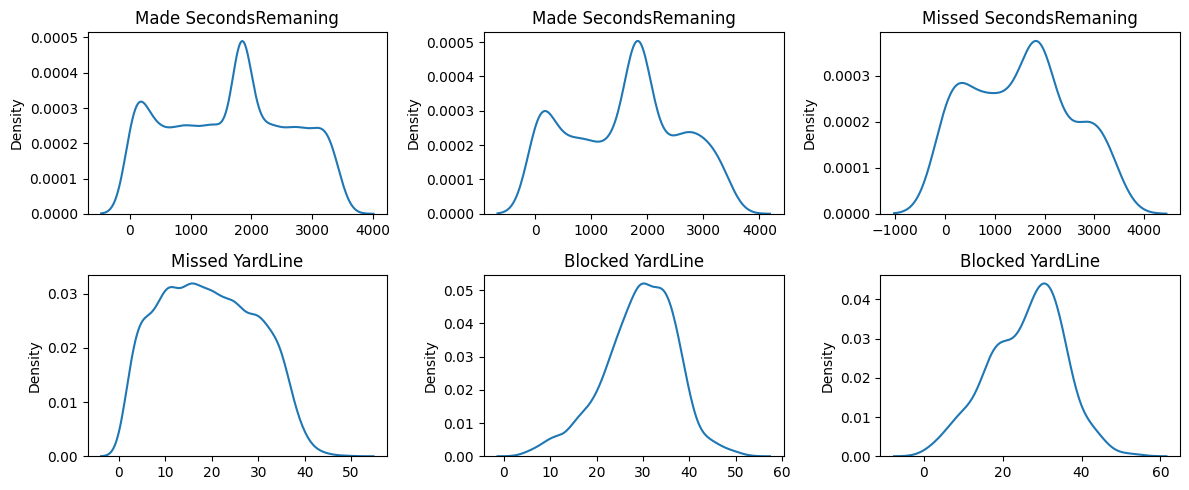

In [14]:

fig, axes = plt.subplots(2, 3, figsize=(12, 5))

sns.kdeplot(data=FGs_made['game_seconds_remaining'], ax=axes[0,0])
sns.kdeplot(data=FGs_made['yardline_100'], ax=axes[1,0])


sns.kdeplot(data=FGs_missed['game_seconds_remaining'], ax=axes[0,1])
sns.kdeplot(data=FGs_missed['yardline_100'], ax=axes[1,1])

sns.kdeplot(data=FGs_blocked['game_seconds_remaining'], ax=axes[0,2])
sns.kdeplot(data=FGs_blocked['yardline_100'], ax=axes[1,2])

axes[0,0].set_title('Made SecondsRemaning')
axes[0,1].set_title('Made SecondsRemaning')
axes[0,2].set_title('Missed SecondsRemaning')
axes[1,0].set_title('Missed YardLine')
axes[1,1].set_title('Blocked YardLine')
axes[1,2].set_title('Blocked YardLine')
plt.tight_layout()
plt.show()

In [15]:
FGs_with_bins = (
    FGs
    .with_columns([
        (pl.col("yardline_100") // 5 * 5).alias("yl_bin_start"),
        ((pl.col("yardline_100") // 5 * 5) + 4).alias("yl_bin_end"),
    ])
    .with_columns([
        ((pl.col("yl_bin_start") + pl.col("yl_bin_end")) / 2).alias("yl_bin_mid")
    ])
)

FG_stats = (
    FGs_with_bins
    .group_by("yl_bin_mid")
    .agg([
        pl.count().alias("total"),
        pl.col("field_goal_result").eq("made").sum().alias("made"),
    ])
    .with_columns([
        (pl.col("made") / pl.col("total")).alias("made_rate")
    ])
    .sort("yl_bin_mid")
)

/tmp/ipykernel_1064/2254633880.py:16: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("total"),


    yl_bin_mid  made_rate
0          2.0   0.992743
1          7.0   0.977389
2         12.0   0.961946
3         17.0   0.922767
4         22.0   0.862069
5         27.0   0.770154
6         32.0   0.718566
7         37.0   0.654750
8         42.0   0.525714
9         47.0   0.289474
10        52.0   0.142857


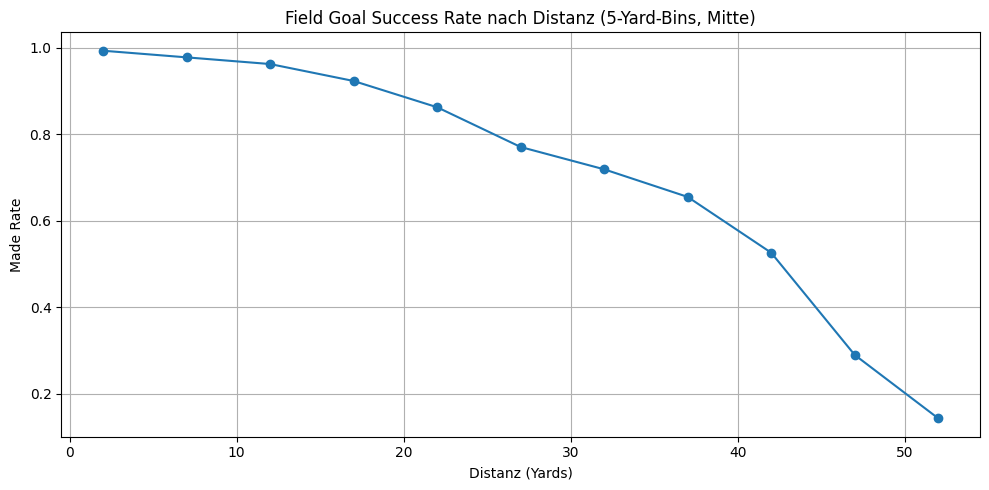

In [ ]:


df_plot = FG_stats.select(["yl_bin_mid", "made_rate"]).to_pandas()
plt.figure(figsize=(10, 5))
plt.plot(df_plot["yl_bin_mid"], df_plot["made_rate"], marker="o")

plt.title("Field Goal Success Rate nach Distanz (5-Yard-Bins, Mitte)")
plt.xlabel("Distanz (Yards)")
plt.ylabel("Made Rate")
plt.grid(True)

plt.tight_layout()
plt.show()